In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Shark Tank India.csv")
df.head(5)

,Season Number,Startup Name,Episode Number,Pitch Number,Season Start,Season End,Original Air Date,Episode Title,Anchor,Industry,...,Invested Guest Name,All Guest Names,Namita Present,Vineeta Present,Anupam Present,Aman Present,Peyush Present,Ritesh Present,Amit Present,Guest Present
0,1,BluePineFoods,1,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Food and Beverage,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
1,1,BoozScooters,1,2,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Vehicles/Electrical Vehicles,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
2,1,HeartUpMySleeves,1,3,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Beauty/Fashion,...,NaN,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
3,1,TagzFoods,2,4,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Food and Beverage,...,Ashneer Grover,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0
4,1,HeadAndHeart,2,5,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Children/Education,...,NaN,Ashneer Grover,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0


In [3]:
df.shape


(634, 80)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 80 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season Number              634 non-null    int64  
 1   Startup Name               634 non-null    object 
 2   Episode Number             634 non-null    int64  
 3   Pitch Number               634 non-null    int64  
 4   Season Start               634 non-null    object 
 5   Season End                 634 non-null    object 
 6   Original Air Date          603 non-null    object 
 7   Episode Title              634 non-null    object 
 8   Anchor                     634 non-null    object 
 9   Industry                   634 non-null    object 
 10  Business Description       634 non-null    object 
 11  Company Website            625 non-null    object 
 12  Started in                 577 non-null    float64
 13  Number of Presenters       634 non-null    int64  

In [5]:
df.isnull().sum()

,0
Season Number,0
Startup Name,0
Episode Number,0
Pitch Number,0
Season Start,0
...,...
Aman Present,78
Peyush Present,246
Ritesh Present,496
Amit Present,497


In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns
cols_to_drop = []
for col in numeric_cols:
    # Check if the maximum value in the column (ignoring NaNs) is greater than 400
    if df[col].max() > 300:
        cols_to_drop.append(col)

print(f"Columns to be dropped: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)
print("DataFrame after dropping columns:")
print(df.head())

Columns to be dropped: ['Pitch Number', 'Started in', 'Yearly Revenue', 'Monthly Sales', 'SKUs', 'Original Ask Amount', 'Valuation Requested', 'Total Deal Amount', 'Deal Valuation', 'Peyush Investment Amount']
DataFrame after dropping columns:
   Season Number      Startup Name  Episode Number Season Start Season End  \
0              1     BluePineFoods               1    20-Dec-21   4-Feb-22   
1              1      BoozScooters               1    20-Dec-21   4-Feb-22   
2              1  HeartUpMySleeves               1    20-Dec-21   4-Feb-22   
3              1         TagzFoods               2    20-Dec-21   4-Feb-22   
4              1      HeadAndHeart               2    20-Dec-21   4-Feb-22   

  Original Air Date                Episode Title           Anchor  \
0         20-Dec-21  Badlegi Business Ki Tasveer  Rannvijay Singh   
1         20-Dec-21  Badlegi Business Ki Tasveer  Rannvijay Singh   
2         20-Dec-21  Badlegi Business Ki Tasveer  Rannvijay Singh   
3         2

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 70 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season Number              634 non-null    int64  
 1   Startup Name               634 non-null    object 
 2   Episode Number             634 non-null    int64  
 3   Season Start               634 non-null    object 
 4   Season End                 634 non-null    object 
 5   Original Air Date          603 non-null    object 
 6   Episode Title              634 non-null    object 
 7   Anchor                     634 non-null    object 
 8   Industry                   634 non-null    object 
 9   Business Description       634 non-null    object 
 10  Company Website            625 non-null    object 
 11  Number of Presenters       634 non-null    int64  
 12  Male Presenters            568 non-null    float64
 13  Female Presenters          382 non-null    float64

In [8]:
missing_values_count = df.isnull().sum()
columns_with_many_missing = missing_values_count[missing_values_count > 300].index.tolist()

print("Columns with more than 300 missing values:")
for col in columns_with_many_missing:
    print(col)

Columns with more than 300 missing values:
Transgender Presenters
Gross Margin
Net Margin
EBITDA
Cash Burn
Has Patents
Bootstrapped
Part of Match off
Total Deal Debt
Debt Interest
Deal Has Conditions
Royalty Percentage
Royalty Recouped Amount
Advisory Shares Equity
Namita Investment Amount
Namita Investment Equity
Namita Debt Amount
Vineeta Investment Amount
Vineeta Investment Equity
Vineeta Debt Amount
Anupam Investment Amount
Anupam Investment Equity
Anupam Debt Amount
Aman Investment Amount
Aman Investment Equity
Aman Debt Amount
Peyush Investment Equity
Peyush Debt Amount
Ritesh Investment Amount
Ritesh Investment Equity
Ritesh Debt Amount
Amit Investment Amount
Amit Investment Equity
Amit Debt Amount
Guest Investment Amount
Guest Investment Equity
Guest Debt Amount
Invested Guest Name
All Guest Names
Ritesh Present
Amit Present
Guest Present


In [9]:
existing_columns_to_drop = [col for col in columns_with_many_missing if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
    print(f"Columns dropped successfully: {existing_columns_to_drop}")
else:
    print("No specified columns found to drop in the DataFrame.")

print("New DataFrame shape:")
print(df.shape)
display(df.head())

Columns dropped successfully: ['Transgender Presenters', 'Gross Margin', 'Net Margin', 'EBITDA', 'Cash Burn', 'Has Patents', 'Bootstrapped', 'Part of Match off', 'Total Deal Debt', 'Debt Interest', 'Deal Has Conditions', 'Royalty Percentage', 'Royalty Recouped Amount', 'Advisory Shares Equity', 'Namita Investment Amount', 'Namita Investment Equity', 'Namita Debt Amount', 'Vineeta Investment Amount', 'Vineeta Investment Equity', 'Vineeta Debt Amount', 'Anupam Investment Amount', 'Anupam Investment Equity', 'Anupam Debt Amount', 'Aman Investment Amount', 'Aman Investment Equity', 'Aman Debt Amount', 'Peyush Investment Equity', 'Peyush Debt Amount', 'Ritesh Investment Amount', 'Ritesh Investment Equity', 'Ritesh Debt Amount', 'Amit Investment Amount', 'Amit Investment Equity', 'Amit Debt Amount', 'Guest Investment Amount', 'Guest Investment Equity', 'Guest Debt Amount', 'Invested Guest Name', 'All Guest Names', 'Ritesh Present', 'Amit Present', 'Guest Present']
New DataFrame shape:
(634, 

,Season Number,Startup Name,Episode Number,Season Start,Season End,Original Air Date,Episode Title,Anchor,Industry,Business Description,...,Original Offered Equity,Received Offer,Accepted Offer,Total Deal Equity,Number of Sharks in Deal,Namita Present,Vineeta Present,Anupam Present,Aman Present,Peyush Present
0,1,BluePineFoods,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Food and Beverage,Frozen Momos,...,5.0,1,1.0,16.00,3.0,1.0,1.0,1.0,1.0,NaN
1,1,BoozScooters,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Vehicles/Electrical Vehicles,Renting e-bike for mobility in private spaces,...,15.0,1,1.0,50.00,2.0,1.0,1.0,1.0,1.0,NaN
2,1,HeartUpMySleeves,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Beauty/Fashion,Detachable Sleeves,...,10.0,1,1.0,30.00,2.0,1.0,1.0,1.0,1.0,NaN
3,1,TagzFoods,2,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Food and Beverage,Healthy Potato Chips Snacks,...,1.0,1,1.0,2.75,1.0,1.0,1.0,1.0,1.0,NaN
4,1,HeadAndHeart,2,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Children/Education,Brain Development Course,...,5.0,0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Season Number             634 non-null    int64  
 1   Startup Name              634 non-null    object 
 2   Episode Number            634 non-null    int64  
 3   Season Start              634 non-null    object 
 4   Season End                634 non-null    object 
 5   Original Air Date         603 non-null    object 
 6   Episode Title             634 non-null    object 
 7   Anchor                    634 non-null    object 
 8   Industry                  634 non-null    object 
 9   Business Description      634 non-null    object 
 10  Company Website           625 non-null    object 
 11  Number of Presenters      634 non-null    int64  
 12  Male Presenters           568 non-null    float64
 13  Female Presenters         382 non-null    float64
 14  Couple Pre

In [11]:
columns_to_remove = ['Peyush Present']

existing_columns_to_remove = [col for col in columns_to_remove if col in df.columns]

if existing_columns_to_remove:
    df = df.drop(columns=existing_columns_to_remove)
    print(f"Columns removed successfully: {existing_columns_to_remove}")
else:
    print("Column 'Peyush Present' not found in the DataFrame.")

print("New DataFrame shape:")
print(df.shape)
display(df.head())

Columns removed successfully: ['Peyush Present']
New DataFrame shape:
(634, 27)


,Season Number,Startup Name,Episode Number,Season Start,Season End,Original Air Date,Episode Title,Anchor,Industry,Business Description,...,Pitchers State,Original Offered Equity,Received Offer,Accepted Offer,Total Deal Equity,Number of Sharks in Deal,Namita Present,Vineeta Present,Anupam Present,Aman Present
0,1,BluePineFoods,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Food and Beverage,Frozen Momos,...,Delhi,5.0,1,1.0,16.00,3.0,1.0,1.0,1.0,1.0
1,1,BoozScooters,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Vehicles/Electrical Vehicles,Renting e-bike for mobility in private spaces,...,Gujarat,15.0,1,1.0,50.00,2.0,1.0,1.0,1.0,1.0
2,1,HeartUpMySleeves,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Beauty/Fashion,Detachable Sleeves,...,Delhi,10.0,1,1.0,30.00,2.0,1.0,1.0,1.0,1.0
3,1,TagzFoods,2,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Food and Beverage,Healthy Potato Chips Snacks,...,Karnataka,1.0,1,1.0,2.75,1.0,1.0,1.0,1.0,1.0
4,1,HeadAndHeart,2,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Children/Education,Brain Development Course,...,Punjab,5.0,0,NaN,NaN,NaN,1.0,1.0,1.0,1.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Season Number             634 non-null    int64  
 1   Startup Name              634 non-null    object 
 2   Episode Number            634 non-null    int64  
 3   Season Start              634 non-null    object 
 4   Season End                634 non-null    object 
 5   Original Air Date         603 non-null    object 
 6   Episode Title             634 non-null    object 
 7   Anchor                    634 non-null    object 
 8   Industry                  634 non-null    object 
 9   Business Description      634 non-null    object 
 10  Company Website           625 non-null    object 
 11  Number of Presenters      634 non-null    int64  
 12  Male Presenters           568 non-null    float64
 13  Female Presenters         382 non-null    float64
 14  Couple Pre

In [13]:
for column in df.columns:
    if df[column].isnull().any():
        # Calculate the mode. .mode()[0] handles cases with multiple modes
        mode_val = df[column].mode()[0]
        df[column].fillna(mode_val, inplace=True)
        print(f"Missing values in column '{column}' filled with mode: {mode_val}")

print("\nDataFrame after filling missing values with mode:")
df.info()

Missing values in column 'Original Air Date' filled with mode: 4-Feb-22
Missing values in column 'Company Website' filled with mode: http://bhaskarspuranpolighar.in/
Missing values in column 'Male Presenters' filled with mode: 1.0
Missing values in column 'Female Presenters' filled with mode: 1.0
Missing values in column 'Pitchers City' filled with mode: Mumbai
Missing values in column 'Pitchers State' filled with mode: Maharashtra
Missing values in column 'Accepted Offer' filled with mode: 1.0
Missing values in column 'Total Deal Equity' filled with mode: 10.0
Missing values in column 'Number of Sharks in Deal' filled with mode: 1.0
Missing values in column 'Namita Present' filled with mode: 1.0
Missing values in column 'Vineeta Present' filled with mode: 1.0
Missing values in column 'Anupam Present' filled with mode: 1.0
Missing values in column 'Aman Present' filled with mode: 1.0

DataFrame after filling missing values with mode:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63

/tmp/ipykernel_41856/3089822666.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mode_val, inplace=True)


In [14]:
df.head(7)

,Season Number,Startup Name,Episode Number,Season Start,Season End,Original Air Date,Episode Title,Anchor,Industry,Business Description,...,Pitchers State,Original Offered Equity,Received Offer,Accepted Offer,Total Deal Equity,Number of Sharks in Deal,Namita Present,Vineeta Present,Anupam Present,Aman Present
0,1,BluePineFoods,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Food and Beverage,Frozen Momos,...,Delhi,5.00,1,1.0,16.00,3.0,1.0,1.0,1.0,1.0
1,1,BoozScooters,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Vehicles/Electrical Vehicles,Renting e-bike for mobility in private spaces,...,Gujarat,15.00,1,1.0,50.00,2.0,1.0,1.0,1.0,1.0
2,1,HeartUpMySleeves,1,20-Dec-21,4-Feb-22,20-Dec-21,Badlegi Business Ki Tasveer,Rannvijay Singh,Beauty/Fashion,Detachable Sleeves,...,Delhi,10.00,1,1.0,30.00,2.0,1.0,1.0,1.0,1.0
3,1,TagzFoods,2,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Food and Beverage,Healthy Potato Chips Snacks,...,Karnataka,1.00,1,1.0,2.75,1.0,1.0,1.0,1.0,1.0
4,1,HeadAndHeart,2,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Children/Education,Brain Development Course,...,Punjab,5.00,0,1.0,10.00,1.0,1.0,1.0,1.0,1.0
5,1,Agritourism,2,20-Dec-21,4-Feb-22,21-Dec-21,"Insaan, Ideas Aur Sapne",Rannvijay Singh,Agriculture,Tourism,...,Maharashtra,5.00,0,1.0,10.00,1.0,1.0,1.0,1.0,1.0
6,1,qZenseLabs,3,20-Dec-21,4-Feb-22,22-Dec-21,Aam Aadmi Ke Business Ideas,Rannvijay Singh,Food and Beverage,Food Freshness Detector,...,"Delhi,Punjab",0.25,1,0.0,10.00,1.0,1.0,1.0,1.0,1.0


In [15]:
columns_to_drop_final = ['Season Start', 'Season End', 'Original Air Date', 'Anchor']
df = df.drop(columns=columns_to_drop_final)
print("DataFrame after dropping specified columns:")
display(df.head())
print("New DataFrame shape:")
print(df.shape)

DataFrame after dropping specified columns:


,Season Number,Startup Name,Episode Number,Episode Title,Industry,Business Description,Company Website,Number of Presenters,Male Presenters,Female Presenters,...,Pitchers State,Original Offered Equity,Received Offer,Accepted Offer,Total Deal Equity,Number of Sharks in Deal,Namita Present,Vineeta Present,Anupam Present,Aman Present
0,1,BluePineFoods,1,Badlegi Business Ki Tasveer,Food and Beverage,Frozen Momos,https://bluepinefoods.com/,3,2.0,1.0,...,Delhi,5.0,1,1.0,16.00,3.0,1.0,1.0,1.0,1.0
1,1,BoozScooters,1,Badlegi Business Ki Tasveer,Vehicles/Electrical Vehicles,Renting e-bike for mobility in private spaces,https://www.boozup.net/,1,1.0,1.0,...,Gujarat,15.0,1,1.0,50.00,2.0,1.0,1.0,1.0,1.0
2,1,HeartUpMySleeves,1,Badlegi Business Ki Tasveer,Beauty/Fashion,Detachable Sleeves,https://heartupmysleeves.com/,1,1.0,1.0,...,Delhi,10.0,1,1.0,30.00,2.0,1.0,1.0,1.0,1.0
3,1,TagzFoods,2,"Insaan, Ideas Aur Sapne",Food and Beverage,Healthy Potato Chips Snacks,https://tagzfoods.com/,2,2.0,1.0,...,Karnataka,1.0,1,1.0,2.75,1.0,1.0,1.0,1.0,1.0
4,1,HeadAndHeart,2,"Insaan, Ideas Aur Sapne",Children/Education,Brain Development Course,https://thehnh.in/,4,1.0,3.0,...,Punjab,5.0,0,1.0,10.00,1.0,1.0,1.0,1.0,1.0


New DataFrame shape:
(634, 23)


In [16]:
df['Sharks Present Count'] = df[['Namita Present', 'Vineeta Present', 'Anupam Present', 'Aman Present']].sum(axis=1)
display(df[['Startup Name', 'Namita Present', 'Vineeta Present', 'Anupam Present', 'Aman Present', 'Sharks Present Count']].head())

,Startup Name,Namita Present,Vineeta Present,Anupam Present,Aman Present,Sharks Present Count
0,BluePineFoods,1.0,1.0,1.0,1.0,4.0
1,BoozScooters,1.0,1.0,1.0,1.0,4.0
2,HeartUpMySleeves,1.0,1.0,1.0,1.0,4.0
3,TagzFoods,1.0,1.0,1.0,1.0,4.0
4,HeadAndHeart,1.0,1.0,1.0,1.0,4.0


In [17]:
print(df.columns.tolist())

['Season Number', 'Startup Name', 'Episode Number', 'Episode Title', 'Industry', 'Business Description', 'Company Website', 'Number of Presenters', 'Male Presenters', 'Female Presenters', 'Couple Presenters', 'Pitchers Average Age', 'Pitchers City', 'Pitchers State', 'Original Offered Equity', 'Received Offer', 'Accepted Offer', 'Total Deal Equity', 'Number of Sharks in Deal', 'Namita Present', 'Vineeta Present', 'Anupam Present', 'Aman Present', 'Sharks Present Count']


### Industry-wise Comparison of Original Offered Equity and Received Offer

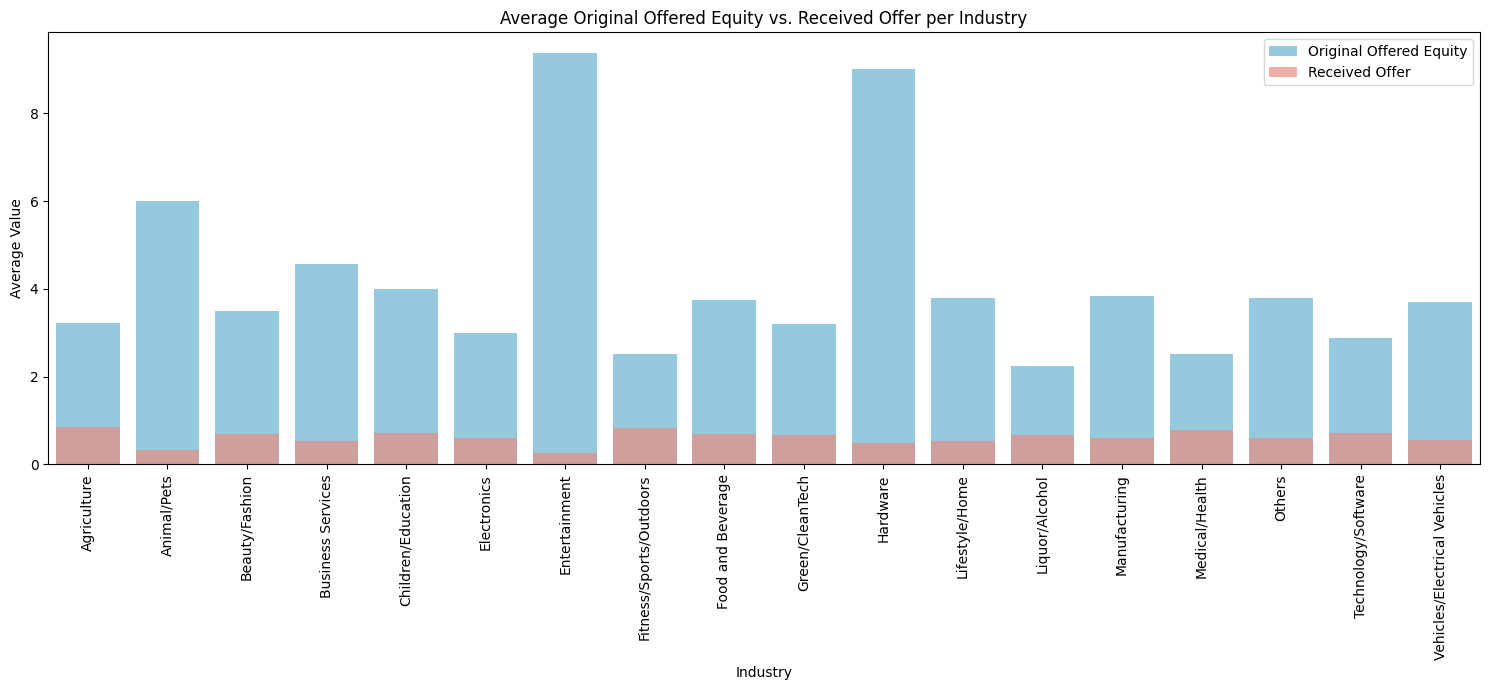

In [18]:
industry_equity_offer = df.groupby('Industry')[['Original Offered Equity', 'Received Offer']].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.barplot(x='Industry', y='Original Offered Equity', data=industry_equity_offer, color='skyblue', label='Original Offered Equity')
sns.barplot(x='Industry', y='Received Offer', data=industry_equity_offer, color='salmon', label='Received Offer', alpha=0.7)
plt.xlabel('Industry')
plt.ylabel('Average Value')
plt.title('Average Original Offered Equity vs. Received Offer per Industry')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

### Comparison of Presenter Types and Number of Sharks in Deal

/tmp/ipykernel_41856/2715327586.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Presenter Type', y='Number of Sharks in Deal', data=presenter_sharks_comparison, palette='viridis')


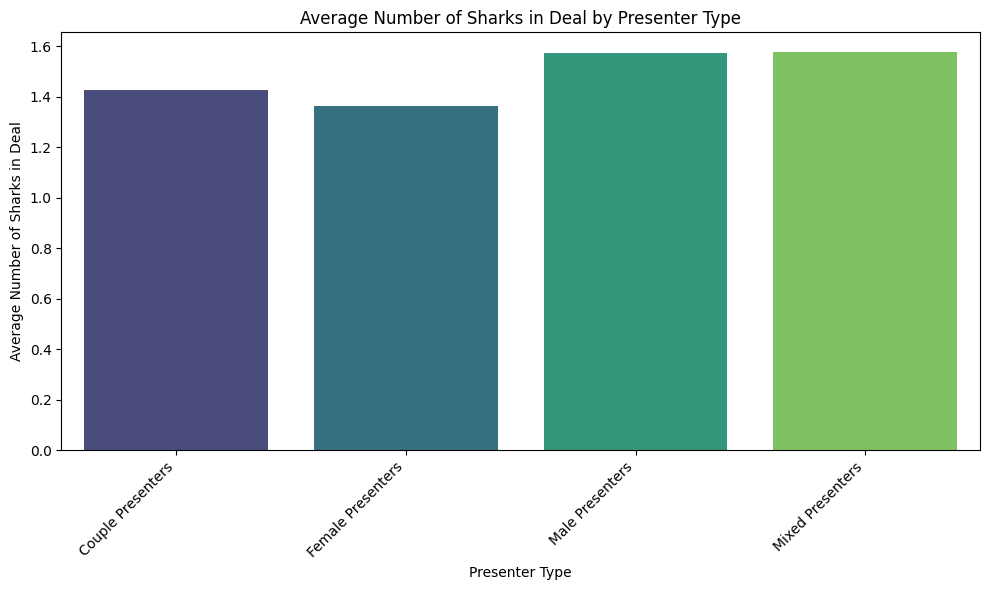

In [19]:
def get_presenter_type(row):
    if row['Couple Presenters'] == 1:
        return 'Couple Presenters'
    elif row['Male Presenters'] >= 1 and row['Female Presenters'] == 0:
        return 'Male Presenters'
    elif row['Female Presenters'] >= 1 and row['Male Presenters'] == 0:
        return 'Female Presenters'
    elif row['Male Presenters'] >= 1 and row['Female Presenters'] >= 1:
        return 'Mixed Presenters'
    else:
        return 'Other'

df['Presenter Type'] = df.apply(get_presenter_type, axis=1)

presenter_sharks_comparison = df.groupby('Presenter Type')['Number of Sharks in Deal'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Presenter Type', y='Number of Sharks in Deal', data=presenter_sharks_comparison, palette='viridis')
plt.xlabel('Presenter Type')
plt.ylabel('Average Number of Sharks in Deal')
plt.title('Average Number of Sharks in Deal by Presenter Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Top 7 States with Most Founders

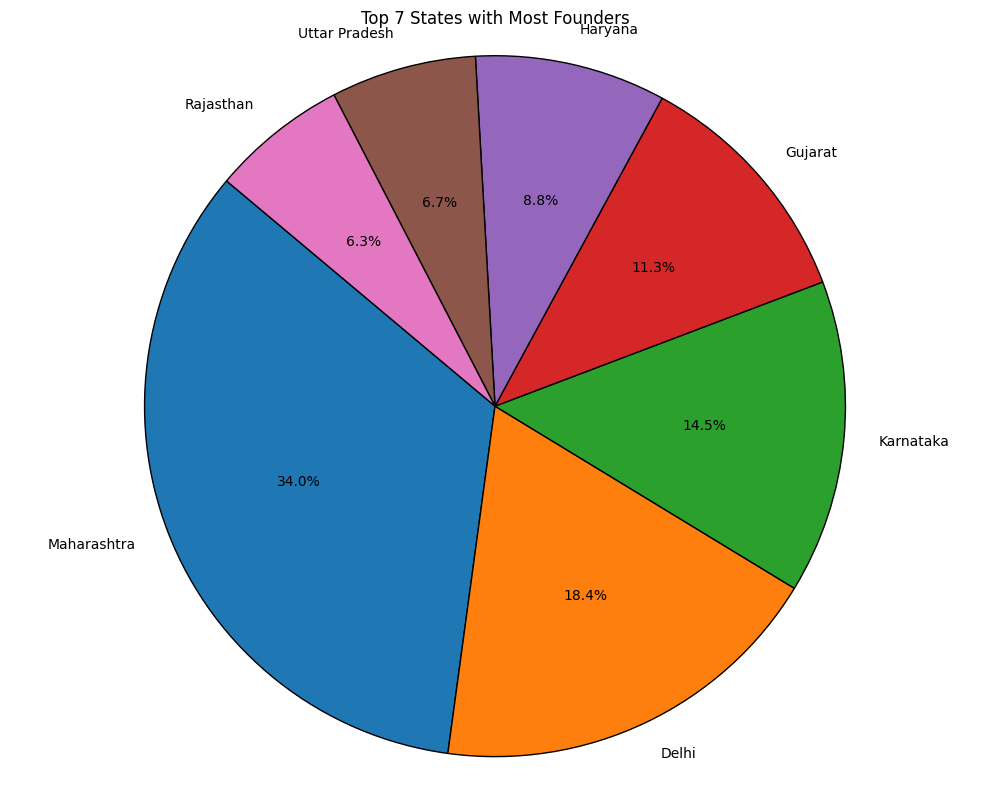

In [20]:
top_states = df['Pitchers State'].value_counts().nlargest(7)

plt.figure(figsize=(10, 8))
plt.pie(top_states, labels=top_states.index, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Top 7 States with Most Founders')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

In [21]:
df = pd.read_csv("Shark Tank India.csv")

# 1. Drop columns where numeric values exceed 300 (original request was 400, then user changed to 300)
numeric_cols = df.select_dtypes(include=np.number).columns
cols_to_drop_high_values = []
for col in numeric_cols:
    if df[col].max() > 300:
        cols_to_drop_high_values.append(col)

df = df.drop(columns=cols_to_drop_high_values, errors='ignore')

# 2. Drop columns with more than 300 missing values
missing_values_count = df.isnull().sum()
columns_with_many_missing = missing_values_count[missing_values_count > 300].index.tolist()
df = df.drop(columns=columns_with_many_missing, errors='ignore')

# 3. Drop specific columns requested by the user
columns_to_remove_explicit = ['Peyush Present', 'Season Start', 'Season End', 'Original Air Date', 'Anchor']
df = df.drop(columns=columns_to_remove_explicit, errors='ignore')


# Fill NaN in 'Accepted Offer' with 0 (as NaN logically means no offer was accepted)
df['Accepted Offer'] = df['Accepted Offer'].fillna(0)
\
columns_to_fill_zero = ['Male Presenters', 'Female Presenters', 'Number of Sharks in Deal',
                        'Namita Present', 'Vineeta Present', 'Anupam Present', 'Aman Present']
for col in columns_to_fill_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Fill remaining NaNs in other columns with their mode as previously requested for general missing values
for column in df.columns:
    if df[column].isnull().any():
        mode_val = df[column].mode()[0]
        df[column].fillna(mode_val, inplace=True)

# Ensure 'Accepted Offer' is 0 if 'Received Offer' is 0
df.loc[df['Received Offer'] == 0, 'Accepted Offer'] = 0

# Create 'Sharks Present Count' (re-created after potential reload/re-fillna)
df['Sharks Present Count'] = df[['Namita Present', 'Vineeta Present', 'Anupam Present', 'Aman Present']].sum(axis=1)

# --- Re-running the shark comparison with corrected data ---

shark_columns = ['Namita Present', 'Vineeta Present', 'Anupam Present', 'Aman Present']

shark_offer_comparison = pd.DataFrame(columns=['Shark', 'Deals Where Shark Present', 'Received Deals', 'Accepted Deals', 'Difference (Received - Accepted)', 'Acceptance Rate'])

for col in shark_columns:
    shark_name = col.replace(' Present', '')

    # Filter data for when the shark was present (now correctly populated with 0 for NaN)
    df_shark_present = df[df[col] == 1].copy()

    # Calculate counts
    deals_shark_present = len(df_shark_present)
    received_deals_count = df_shark_present['Received Offer'].sum()
    accepted_deals_count = df_shark_present['Accepted Offer'].sum()

    # Calculate difference and acceptance rate
    difference = received_deals_count - accepted_deals_count
    acceptance_rate = (accepted_deals_count / received_deals_count) * 100 if received_deals_count > 0 else 0

    shark_offer_comparison.loc[len(shark_offer_comparison)] = [
        shark_name, deals_shark_present, received_deals_count, accepted_deals_count, difference, acceptance_rate
    ]

display(shark_offer_comparison)


/tmp/ipykernel_41856/1325855024.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mode_val, inplace=True)


,Shark,Deals Where Shark Present,Received Deals,Accepted Deals,Difference (Received - Accepted),Acceptance Rate
0,Namita,495,343,297.0,46.0,86.588921
1,Vineeta,428,298,254.0,44.0,85.234899
2,Anupam,548,374,323.0,51.0,86.363636
3,Aman,556,383,331.0,52.0,86.422977


/tmp/ipykernel_41856/1137390535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Shark', y='Difference (Received - Accepted)', data=shark_offer_comparison, palette='coolwarm')
/tmp/ipykernel_41856/1137390535.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Shark', y='Acceptance Rate', data=shark_offer_comparison, palette='viridis')


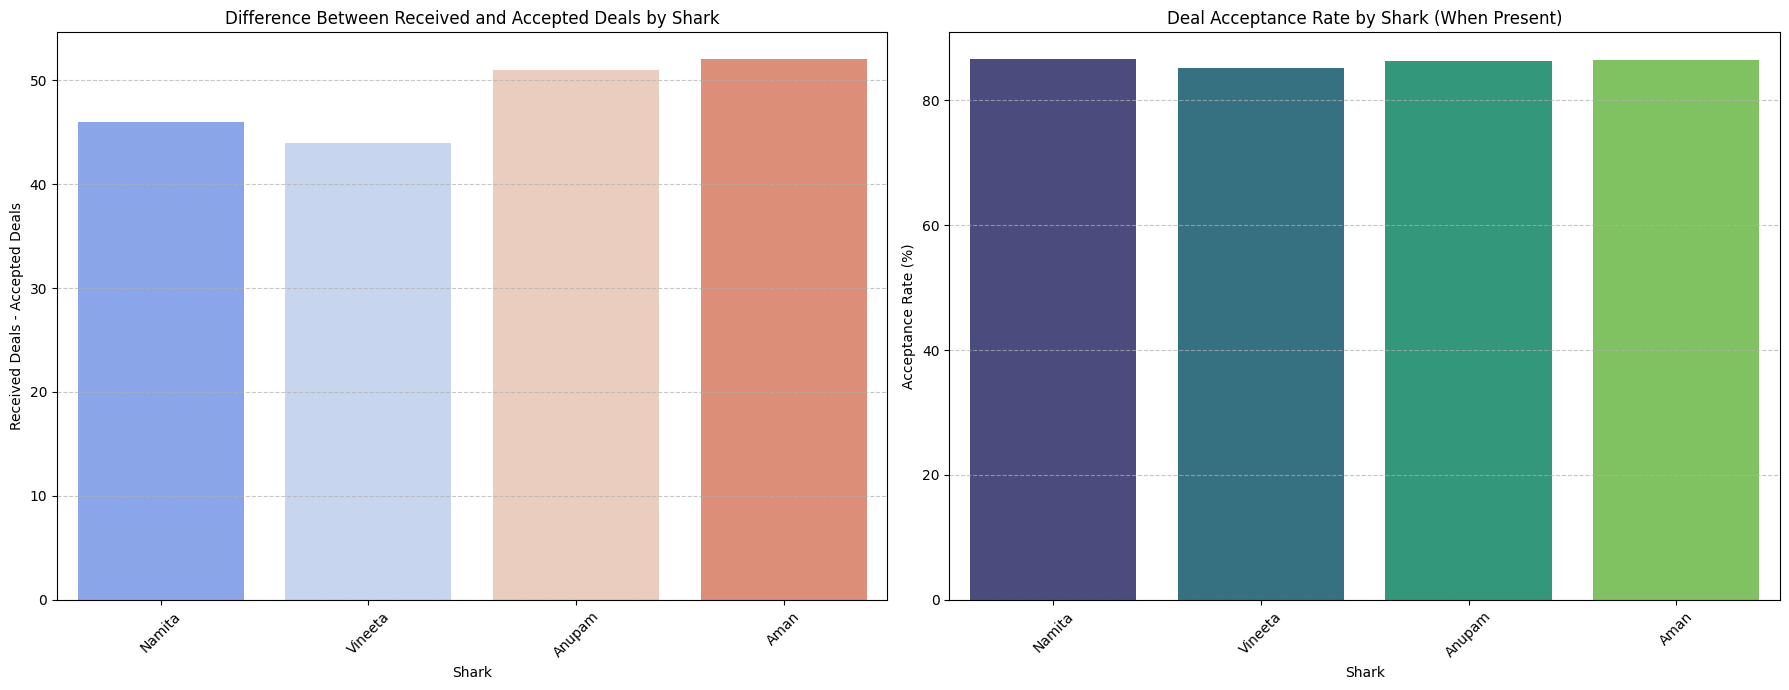

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart for Difference (Received - Accepted)
sns.barplot(ax=axes[0], x='Shark', y='Difference (Received - Accepted)', data=shark_offer_comparison, palette='coolwarm')
axes[0].set_title('Difference Between Received and Accepted Deals by Shark')
axes[0].set_ylabel('Received Deals - Accepted Deals')
axes[0].set_xlabel('Shark')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Bar chart for Acceptance Rate
sns.barplot(ax=axes[1], x='Shark', y='Acceptance Rate', data=shark_offer_comparison, palette='viridis')
axes[1].set_title('Deal Acceptance Rate by Shark (When Present)')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].set_xlabel('Shark')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [26]:
# Which shark secured more deals?
most_deals_shark = shark_offer_comparison.sort_values(by='Accepted Deals', ascending=False).iloc[0]
print(f"The shark who secured the most deals is {most_deals_shark['Shark']} with {int(most_deals_shark['Accepted Deals'])} accepted deals.")

# Which industry secured more deals?
industry_deals = df.groupby('Industry')['Accepted Offer'].sum().sort_values(ascending=False)
most_deals_industry = industry_deals.index[0]
num_deals_industry = int(industry_deals.iloc[0])
print(f"The industry that secured the most deals is '{most_deals_industry}' with {num_deals_industry} accepted deals.")

print("\nTop 5 Industries by Accepted Deals:")
print(industry_deals.head())

The shark who secured the most deals is Aman with 331 accepted deals.
The industry that secured the most deals is 'Food and Beverage' with 82 accepted deals.

Top 5 Industries by Accepted Deals:
Industry
Food and Beverage      82.0
Beauty/Fashion         74.0
Medical/Health         41.0
Technology/Software    36.0
Manufacturing          26.0
Name: Accepted Offer, dtype: float64


### Top 5 Industries by Accepted Deals

/tmp/ipykernel_41856/3904454139.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_deals.head().index, y=industry_deals.head().values, palette='viridis')


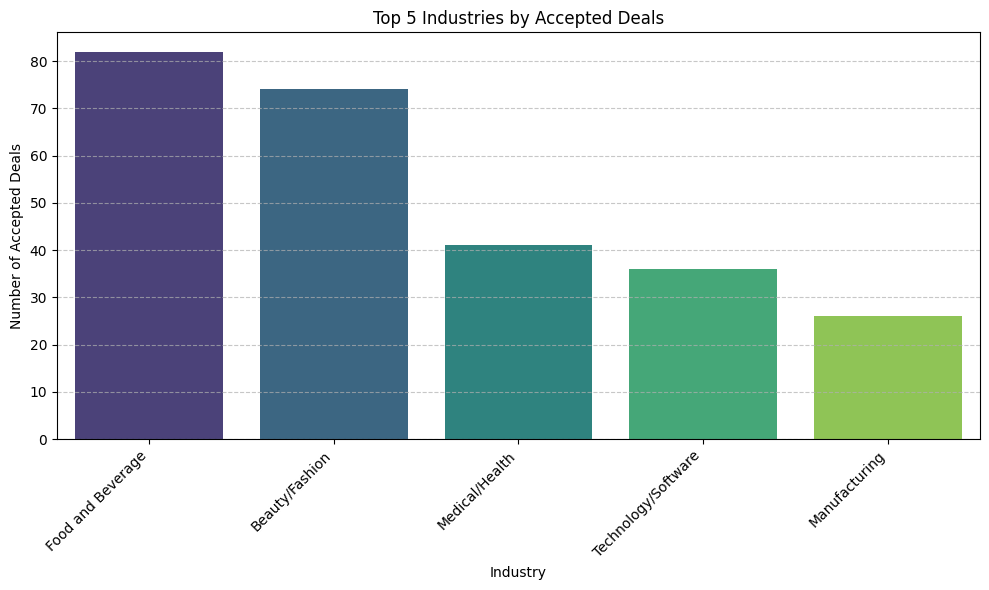

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(x=industry_deals.head().index, y=industry_deals.head().values, palette='viridis')
plt.title('Top 5 Industries by Accepted Deals')
plt.xlabel('Industry')
plt.ylabel('Number of Accepted Deals')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_41856/3797832674.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Shark', y='Accepted Deals', data=shark_offer_comparison.sort_values(by='Accepted Deals', ascending=False), palette='magma')


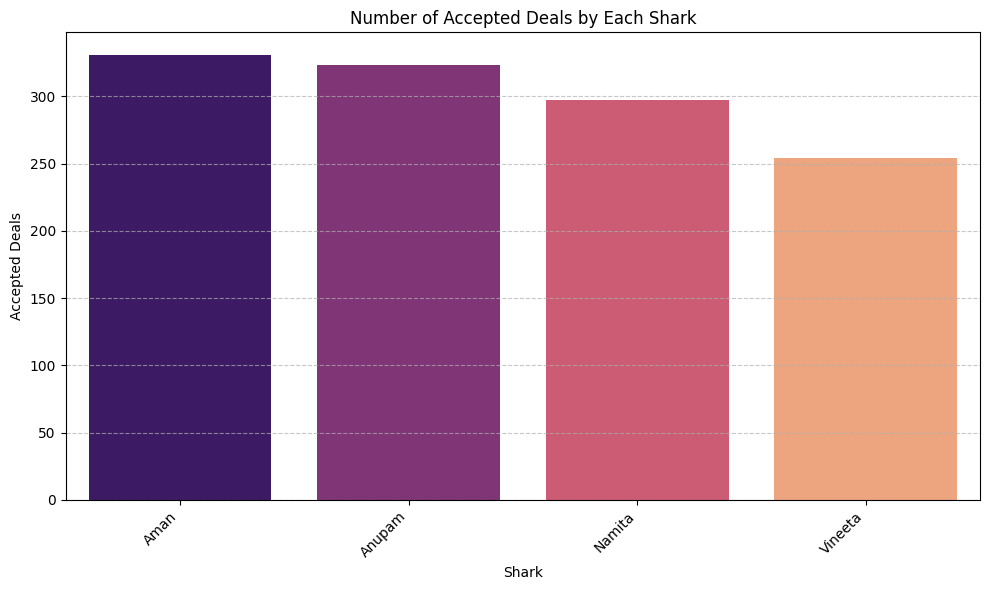

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Shark', y='Accepted Deals', data=shark_offer_comparison.sort_values(by='Accepted Deals', ascending=False), palette='magma')
plt.title('Number of Accepted Deals by Each Shark')
plt.xlabel('Shark')
plt.ylabel('Accepted Deals')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()